In [ ]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
path = kagglehub.dataset_download("tjverry/credit-card-transactions")

print("Path to dataset files:", path)

#this file serves as exploratory data analysis to rule out insignificant features for the training of the autoencoder
#some of the strong features found so far is cardPresent and cvv_Match which shows about a 90% correlation to isFraud
#the fraudulent transaction amount is more centered around the mean but that's likely a result lack of data

100%|██████████| 21.3M/21.3M [00:00<00:00, 67.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tjverry/credit-card-transactions/versions/1


In [ ]:
print(os.listdir(path))

['transactions.csv']


In [ ]:
df = pd.read_csv(path + "/transactions.csv")

df

,accountNumber,creditLimit,availableMoney,transactionDateTime,merchantName,transactionAmount,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,5000,5000.00,2016-08-13T14:27:32,Uber,98.55,US,US,2.0,1.0,...,3/14/2015,3/14/2015,414,414,1803,PURCHASE,0.00,0,0,0
1,737265056,5000,5000.00,2016-10-11T05:05:54,AMC #191138,74.51,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,1,0,0
2,737265056,5000,5000.00,2016-11-08T09:18:39,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,0,0,0
3,737265056,5000,5000.00,2016-12-10T02:14:50,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,0,0,0
4,830329091,5000,5000.00,2016-03-24T21:04:46,Tim Hortons #947751,71.18,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786358,732852505,50000,48904.96,2016-12-22T18:44:12,Lyft,119.92,US,US,90.0,1.0,...,8/23/2012,8/23/2012,936,936,3783,PURCHASE,1095.04,0,0,0
786359,732852505,50000,48785.04,2016-12-25T16:20:34,hulu.com,18.89,US,US,9.0,1.0,...,8/23/2012,8/23/2012,939,939,3388,PURCHASE,1214.96,0,0,0
786360,732852505,50000,48766.15,2016-12-27T15:46:24,Lyft,49.43,US,US,2.0,1.0,...,8/23/2012,8/23/2012,936,936,3783,PURCHASE,1233.85,0,0,0
786361,732852505,50000,48716.72,2016-12-29T00:30:55,walmart.com,49.89,US,US,9.0,99.0,...,8/23/2012,8/23/2012,939,939,3388,PURCHASE,1283.28,0,0,0


<Axes: xlabel='isFraud', ylabel='transactionAmount'>

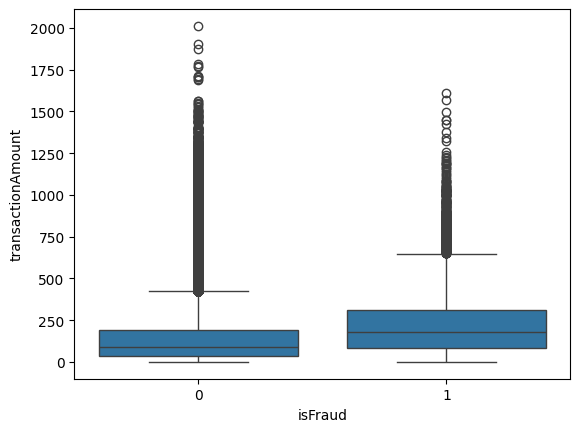

In [ ]:
sns.boxplot(x='isFraud', y='transactionAmount', data=df)

In [ ]:
#Strong feature

df.groupby(['isFraud', 'cardPresent']).size()

isFraud  cardPresent
0        0              424533
         1              349413
1        0                8962
         1                3455
dtype: int64

In [ ]:
#Strong feature

df['cvv_match'] = (df['cardCVV'] == df['enteredCVV']).astype(int)
df.groupby(['isFraud', 'cvv_match']).size()

isFraud  cvv_match
0        0              6812
         1            767134
1        0               203
         1             12214
dtype: int64

<Axes: xlabel='merchantCategoryCode', ylabel='count'>

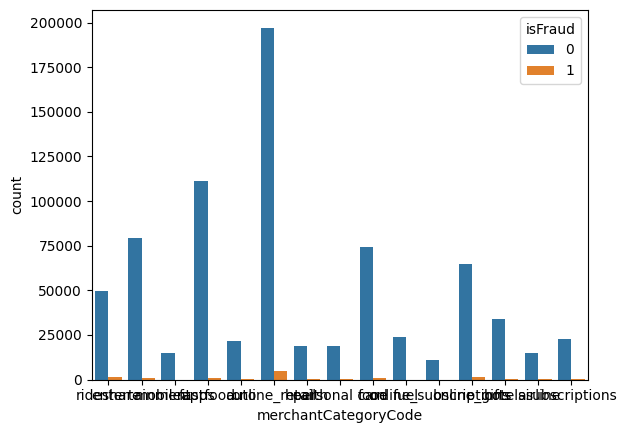

In [ ]:
top_mccs = df['merchantCategoryCode'].value_counts().nlargest(15).index
mcc_df = df[df['merchantCategoryCode'].isin(top_mccs)]

sns.countplot(data=mcc_df, x='merchantCategoryCode', hue='isFraud')

<Axes: xlabel='isFraud', ylabel='amount_to_limit_ratio'>

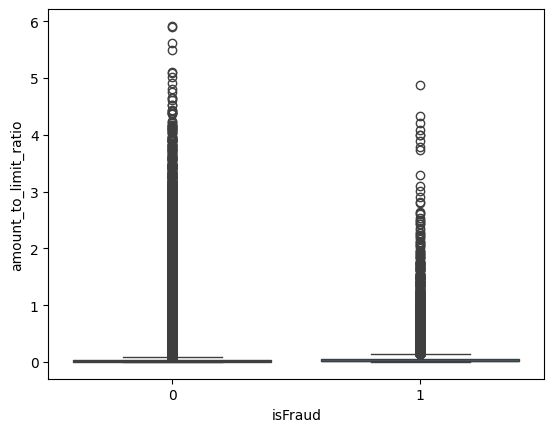

In [ ]:
df['amount_to_limit_ratio'] = df['transactionAmount'] / df['creditLimit']
sns.boxplot(data=df, x='isFraud', y='amount_to_limit_ratio')


<Axes: xlabel='account_age_days', ylabel='Count'>

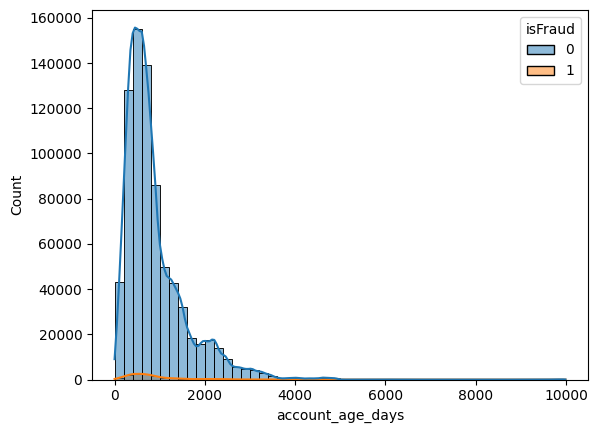

In [ ]:
df['accountOpenDate'] = pd.to_datetime(df['accountOpenDate'])
df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])
df['account_age_days'] = (df['transactionDateTime'] - df['accountOpenDate']).dt.days

sns.histplot(data=df, x='account_age_days', hue='isFraud', bins=50, kde=True)

<Axes: xlabel='posEntryMode', ylabel='count'>

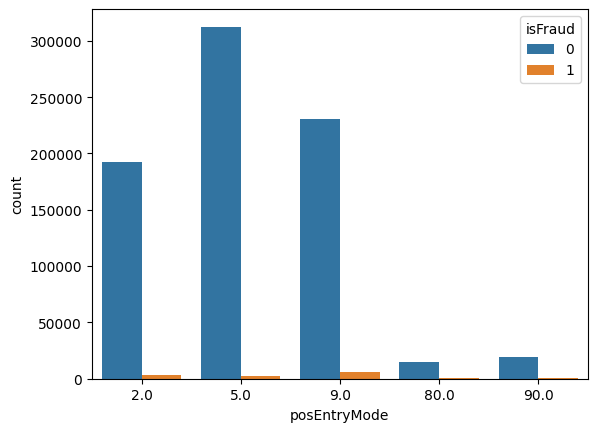

In [ ]:
# ── POS Entry Mode vs Fraud ───────────────────────────────────────────────
sns.countplot(data=df, x='posEntryMode', hue='isFraud')

In [ ]:

# ── Cross-border transaction vs Fraud ─────────────────────────────────────
df['cross_border'] = (df['acqCountryCode'] != df['merchantCountryCode']).astype(int)
sns.countplot(data=df, x='cross_border', hue='isFraud')

KeyError: 'acqCountryCode'

In [ ]:
#Correlation heatmap ───────────────────────────────────────────────────
sns.heatmap(df[['transactionAmount', 'currentBalance', 'creditLimit',
                'availableMoney', 'amount_to_limit_ratio',
                'amount_to_balance_ratio', 'account_age_days',
                'isFraud']].corr(), annot=True, cmap='coolwarm')

KeyError: "['amount_to_balance_ratio'] not in index"